# Análise final — ativações com augmentation 0,5 (Mac M4)

## tl;dr

A rodada local está completa: **27/27 runs**, 2,700 epochs e **99.46 h** de treinamento acumulado. O melhor resultado é **MNIST/Sigmoid** (macro-F1 de teste 98.44%). Nos cinco pares comparáveis com augmentation 2,0, a versão 0,5 reduziu o tempo médio por epoch em **47.8%**, com efeito misto em macro-F1.

## Context & Methods

### Key Assumptions

- O escopo é somente o Mac M4 local: 9 datasets × 3 ativações, seed 42 e 100 epochs por condição.
- Os dados publicados no diretório `docs/augmentation05_final/data/` são snapshots derivados dos artefatos finais locais.
- Os outputs brutos não são versionados por volume; para reextrair os dados é necessário ter os diretórios `outputs/controlled-augmentation*-activations-mac2/`.
- A comparação entre 0,5 e 2,0 usa somente os cinco pares com métricas finais nos dois lados.

## Data

### 1. Load published snapshots

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT = Path.cwd()
REPORT_DIR = PROJECT / 'docs' / 'augmentation05_final'
DATA_DIR = REPORT_DIR / 'data'
FIGURE_DIR = REPORT_DIR / 'figures'
sys.path.insert(0, str(PROJECT / 'scripts'))
from build_augmentation05_final_report import render_figures

runs = pd.read_csv(DATA_DIR / 'resultados_augmentation05.csv')
comparison = pd.read_csv(DATA_DIR / 'comparacao_augmentation20_vs_05.csv')
overview = json.loads((DATA_DIR / 'resumo_augmentation05.json').read_text(encoding='utf-8'))
runs.head()

,dataset_key,dataset,activation_key,activation,status,epochs_completed,test_accuracy,test_balanced_accuracy,test_macro_f1,test_macro_precision,...,gpu_memory_mean_bytes,peak_gpu_memory_bytes,process_cpu_mean_pct,peak_process_cpu_pct,process_rss_mean_bytes,peak_process_rss_bytes,ram_mean_pct,peak_ram_percent,thermal_pressure,metric_path
0,mnist,MNIST,relu,ReLU,completed,100,0.983711,0.983492,0.983603,0.983830,...,9.541790e+08,1.340981e+09,84.269508,154.4,3.039172e+09,4.145889e+09,74.127008,78.6,nominal,outputs/controlled-augmentation05-activations-...
1,mnist,MNIST,sigmoid,Sigmoid,completed,100,0.984568,0.984298,0.984366,0.984474,...,8.124613e+08,1.205895e+09,75.520218,154.9,3.234922e+09,4.292362e+09,73.808336,76.4,nominal,outputs/controlled-augmentation05-activations-...
2,mnist,MNIST,softmax,Softmax,completed,100,0.112498,0.100000,0.020224,0.011250,...,9.544624e+08,1.320796e+09,82.553435,156.6,3.268853e+09,4.648059e+09,74.066010,77.8,nominal,outputs/controlled-augmentation05-activations-...
3,fashion_mnist,Fashion-MNIST,relu,ReLU,completed,100,0.878190,0.878190,0.875010,0.881802,...,9.519808e+08,1.341620e+09,82.597594,156.6,3.179155e+09,4.414652e+09,74.342181,78.8,nominal,outputs/controlled-augmentation05-activations-...
4,fashion_mnist,Fashion-MNIST,sigmoid,Sigmoid,completed,100,0.900476,0.900476,0.900415,0.901995,...,8.105587e+08,1.207288e+09,76.207362,153.9,2.872804e+09,3.932602e+09,75.385583,80.2,nominal,outputs/controlled-augmentation05-activations-...


### 2. Validate final artifacts

In [2]:
assert len(runs) == 27, f'Esperava 27 runs; encontrei {len(runs)}'
assert (runs['status'] == 'completed').all(), 'Há run sem status completed'
assert (runs['epochs_completed'] == 100).all(), 'Há run sem 100 epochs'
assert runs['test_macro_f1'].notna().all(), 'Há macro-F1 final ausente'
print(f"Runs: {len(runs)}; completed: {(runs.status == 'completed').sum()}; epochs: {int(runs.epochs_completed.sum())}")
print(f"Comparações pareadas: {len(comparison)}; telemetria: {overview['hardware_usage']['sample_count']:,} amostras")

Runs: 27; completed: 27; epochs: 2700
Comparações pareadas: 5; telemetria: 75,999 amostras


## Results

### 3. Complete final-result table

In [3]:
display_columns = ['dataset', 'activation', 'test_accuracy', 'test_balanced_accuracy', 'test_macro_f1', 'mean_epoch_seconds', 'training_seconds']
runs[display_columns].assign(training_hours=lambda frame: frame.training_seconds / 3600).drop(columns='training_seconds').round(4)

,dataset,activation,test_accuracy,test_balanced_accuracy,test_macro_f1,mean_epoch_seconds,training_hours
0,MNIST,ReLU,0.9837,0.9835,0.9836,115.1799,3.1994
1,MNIST,Sigmoid,0.9846,0.9843,0.9844,152.3821,4.2328
2,MNIST,Softmax,0.1125,0.1000,0.0202,117.7521,3.2709
3,Fashion-MNIST,ReLU,0.8782,0.8782,0.8750,117.8649,3.2740
4,Fashion-MNIST,Sigmoid,0.9005,0.9005,0.9004,150.3389,4.1761
5,Fashion-MNIST,Softmax,0.1000,0.1000,0.0182,117.1434,3.2540
6,KMNIST,ReLU,0.9702,0.9702,0.9702,115.1295,3.1980
7,KMNIST,Sigmoid,0.9711,0.9711,0.9711,147.1495,3.4335
8,KMNIST,Softmax,0.1000,0.1000,0.0182,116.1734,3.2270
9,EMNIST Balanced,ReLU,0.8486,0.8486,0.8442,236.7506,3.8143


### 4. Regenerate all report figures

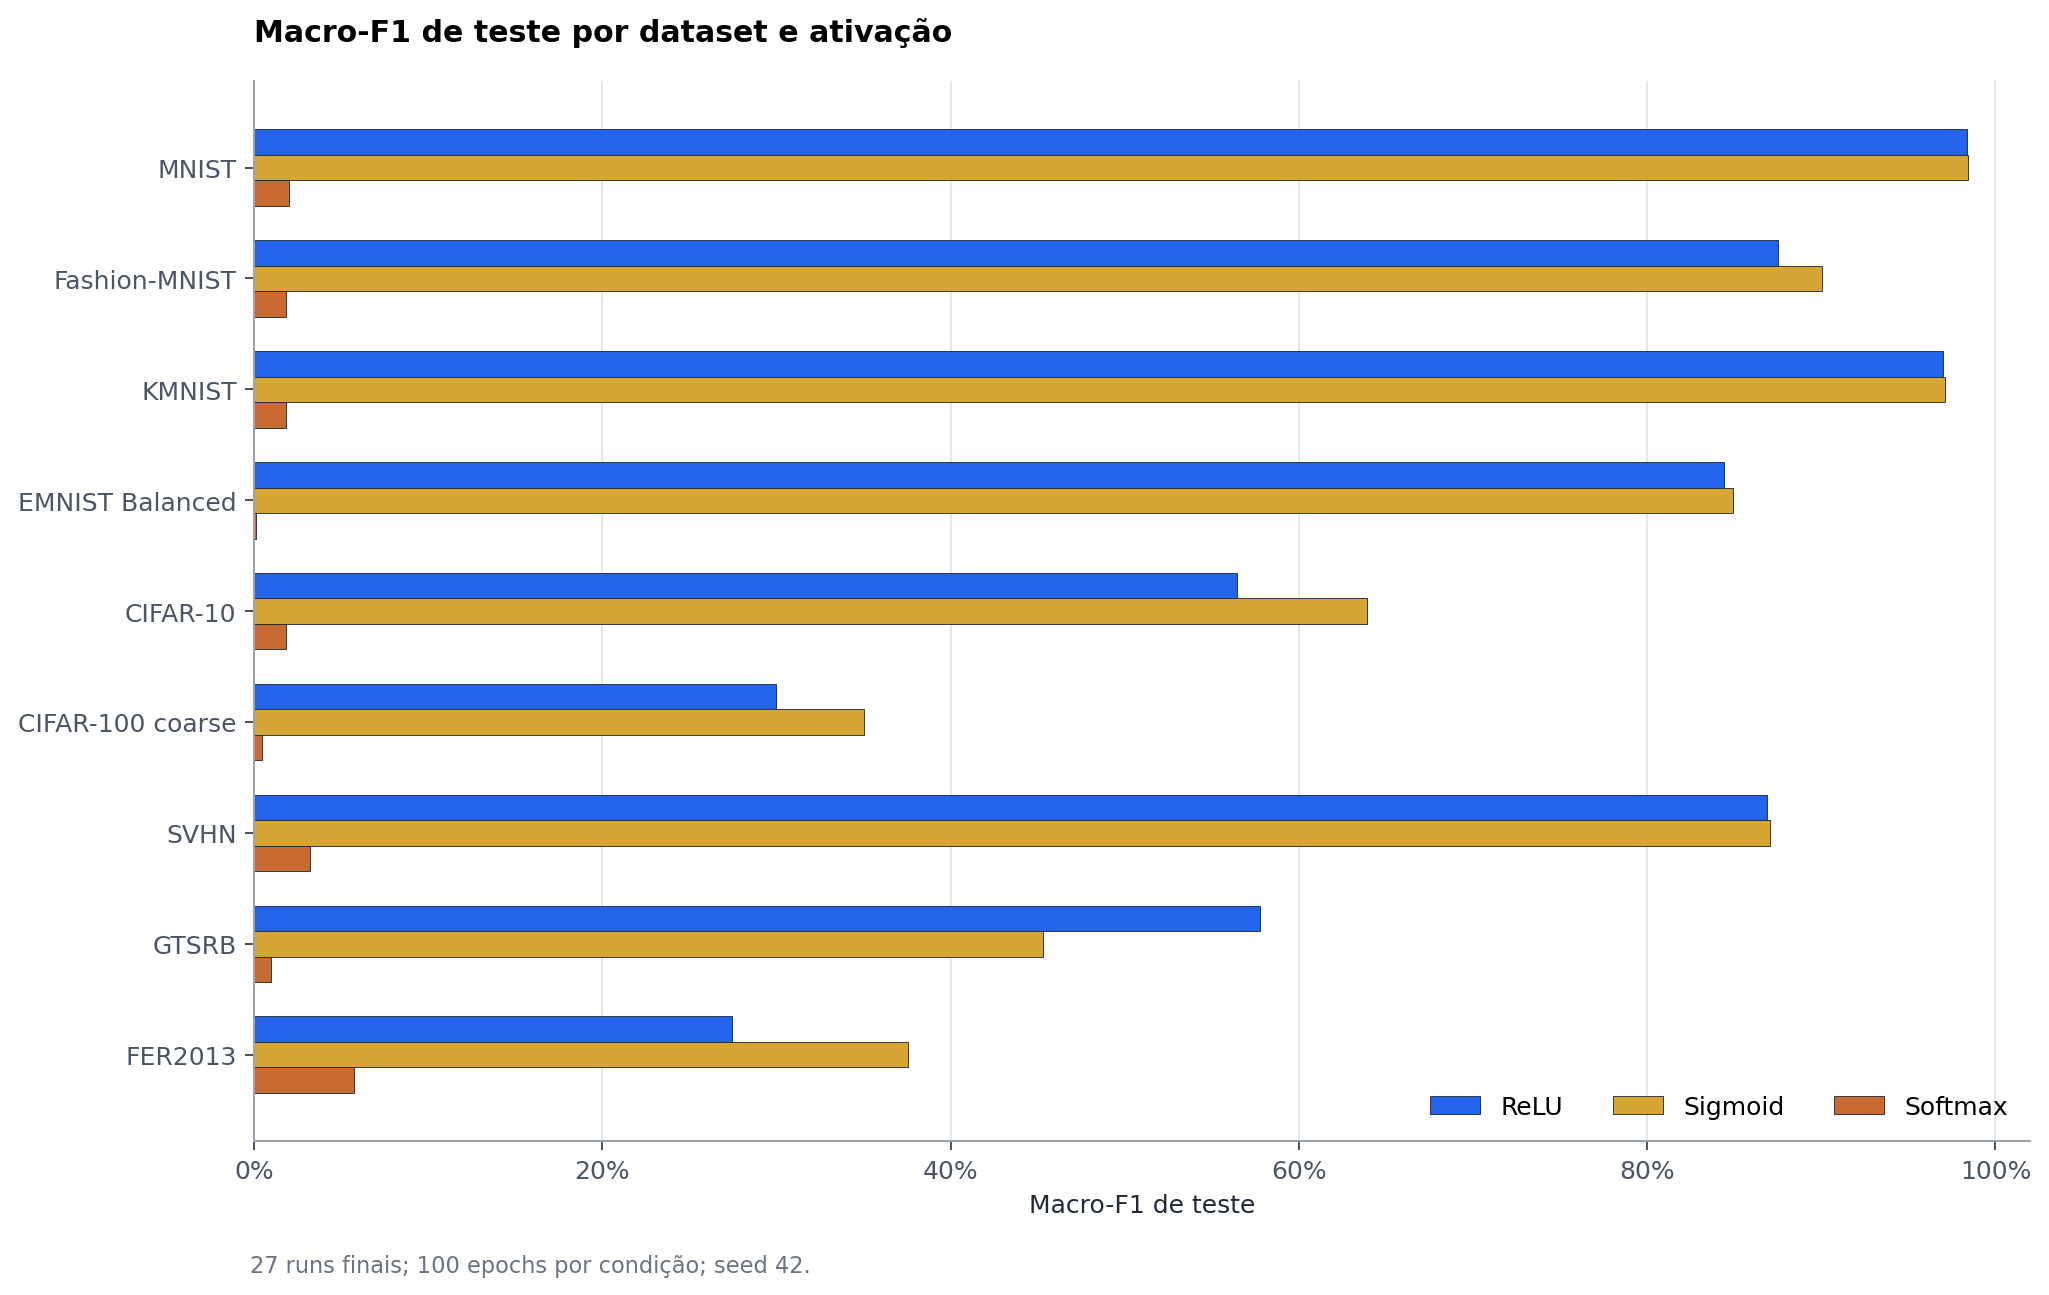

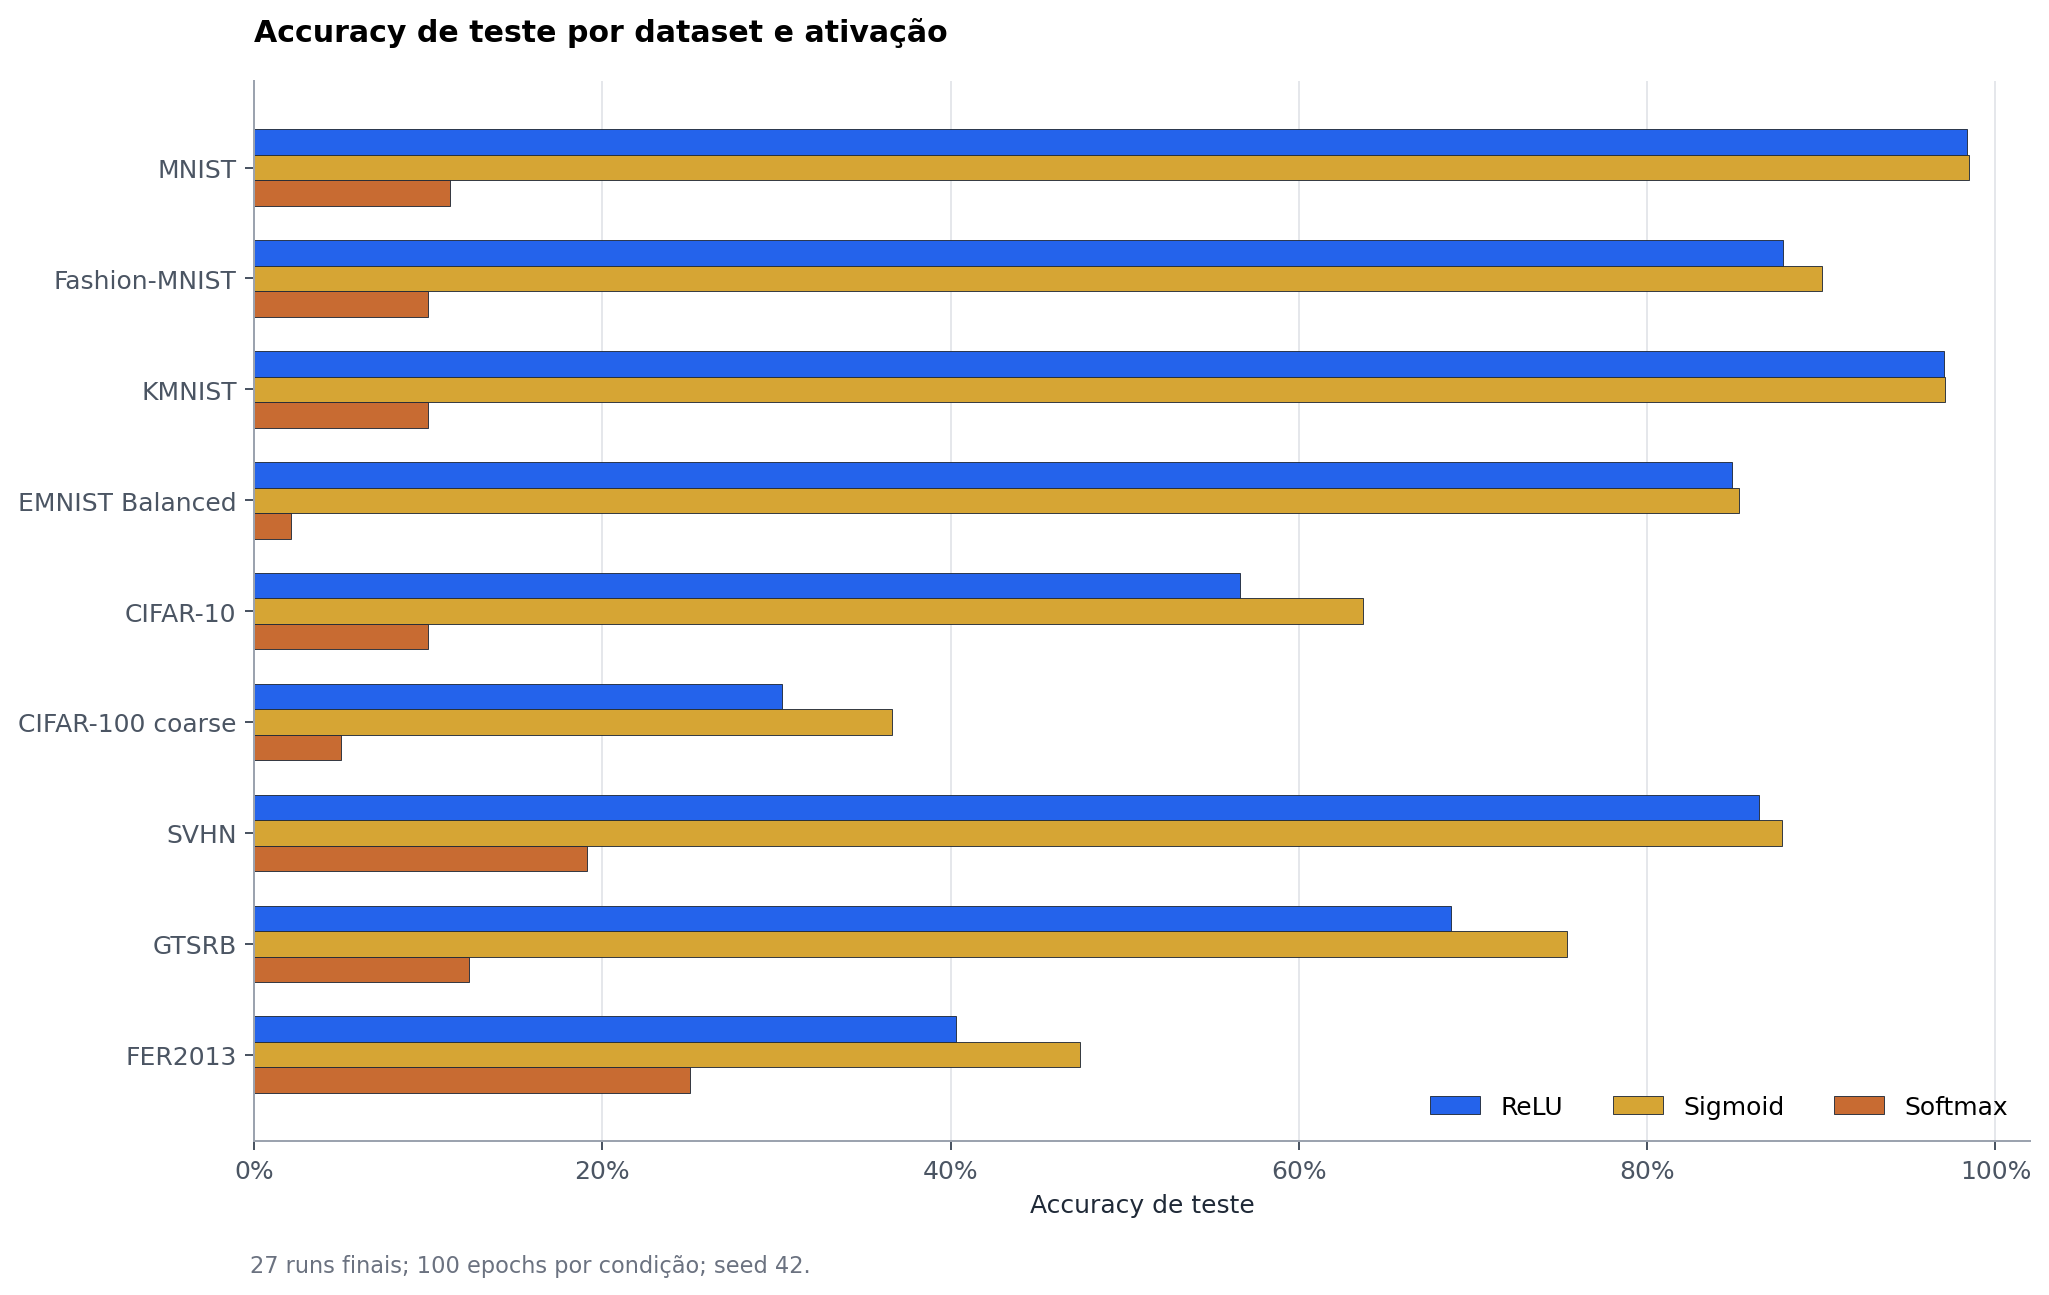

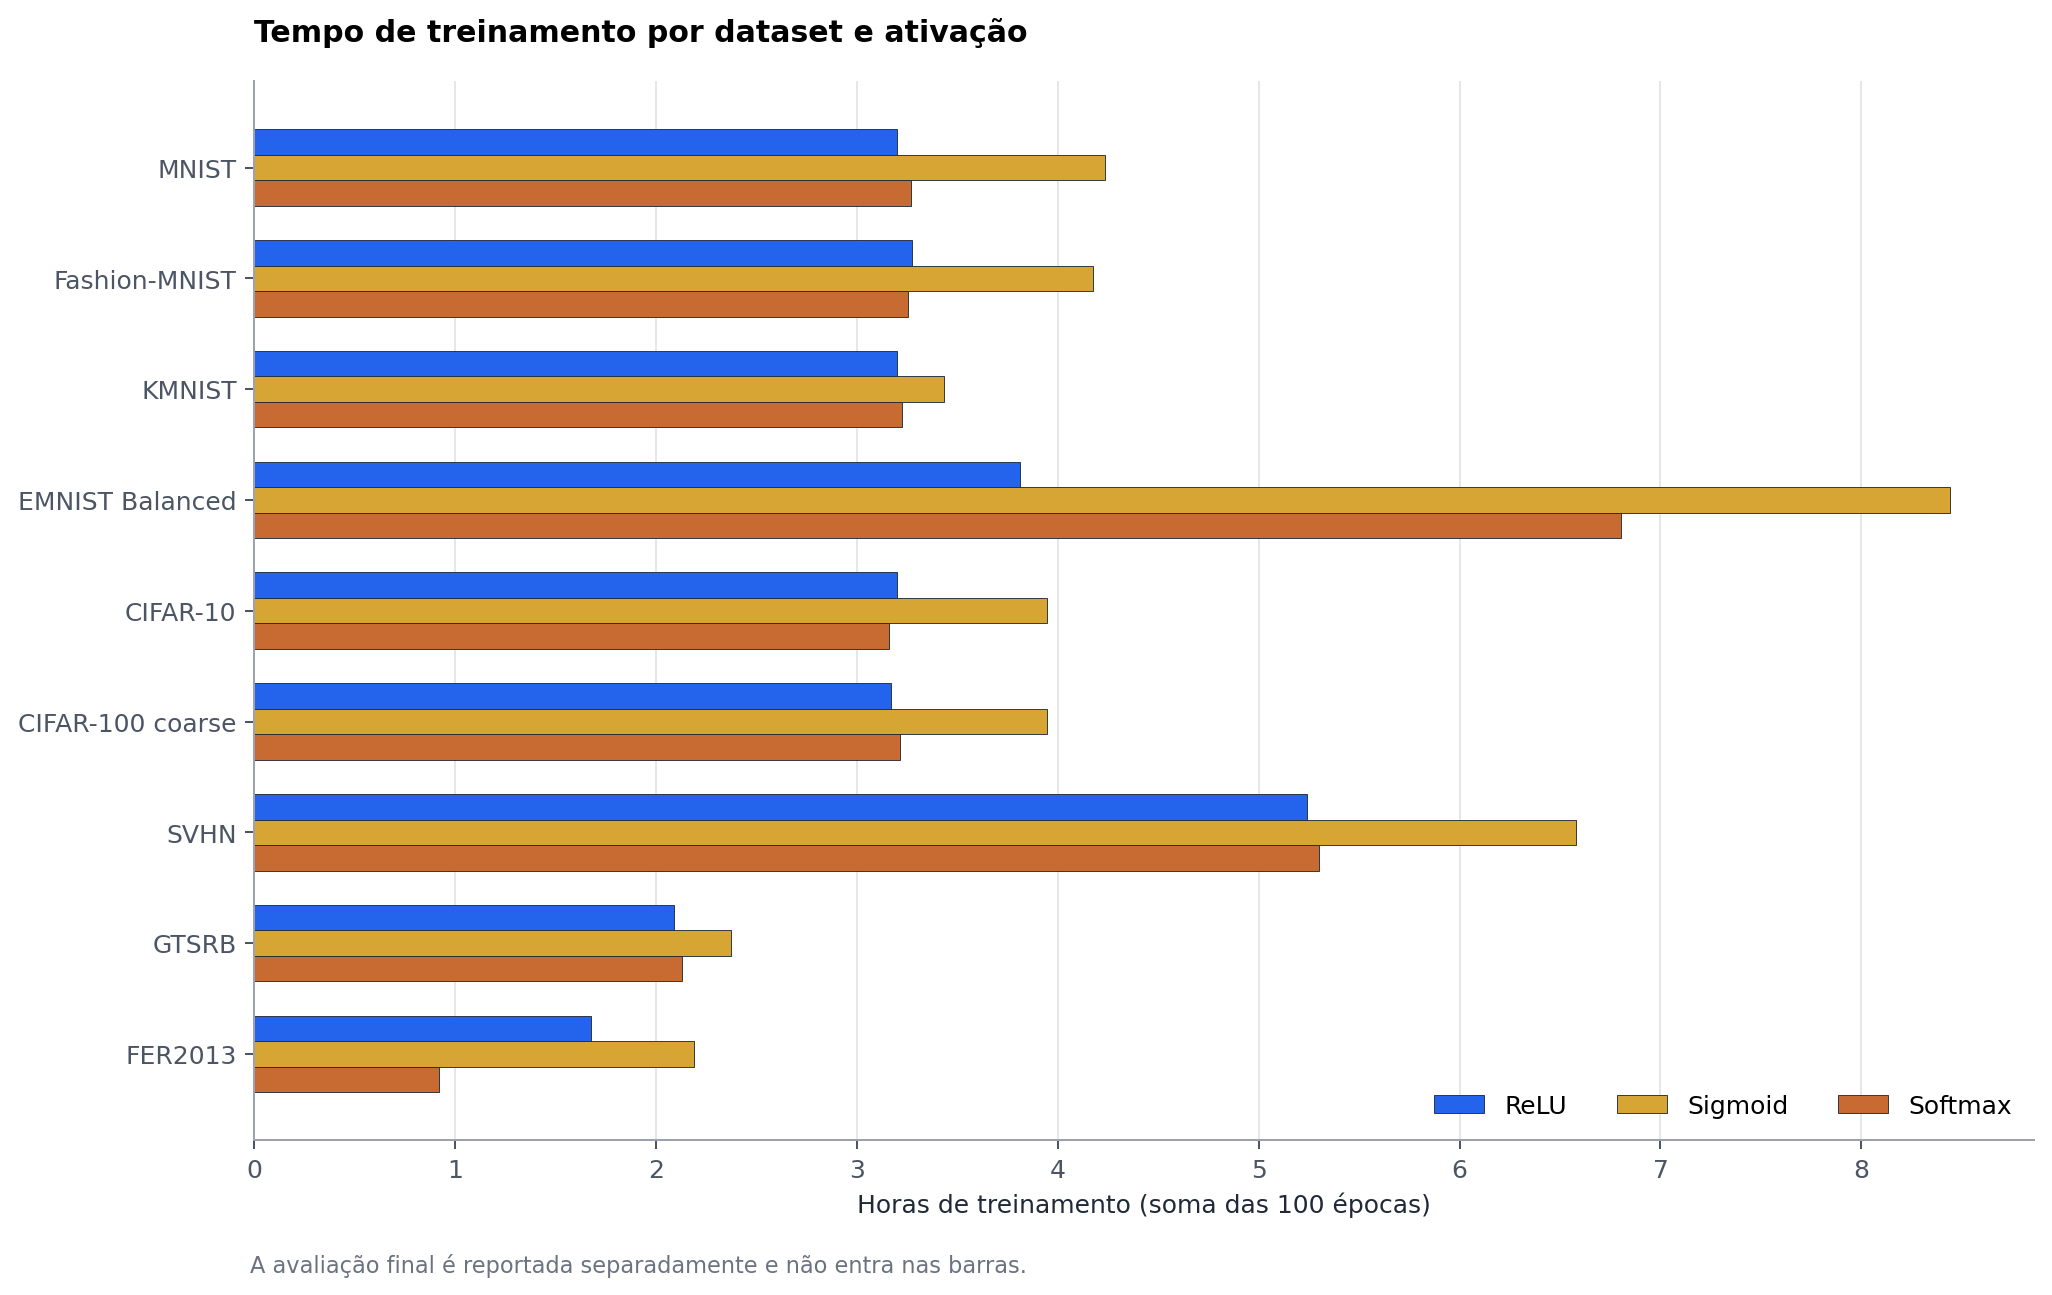

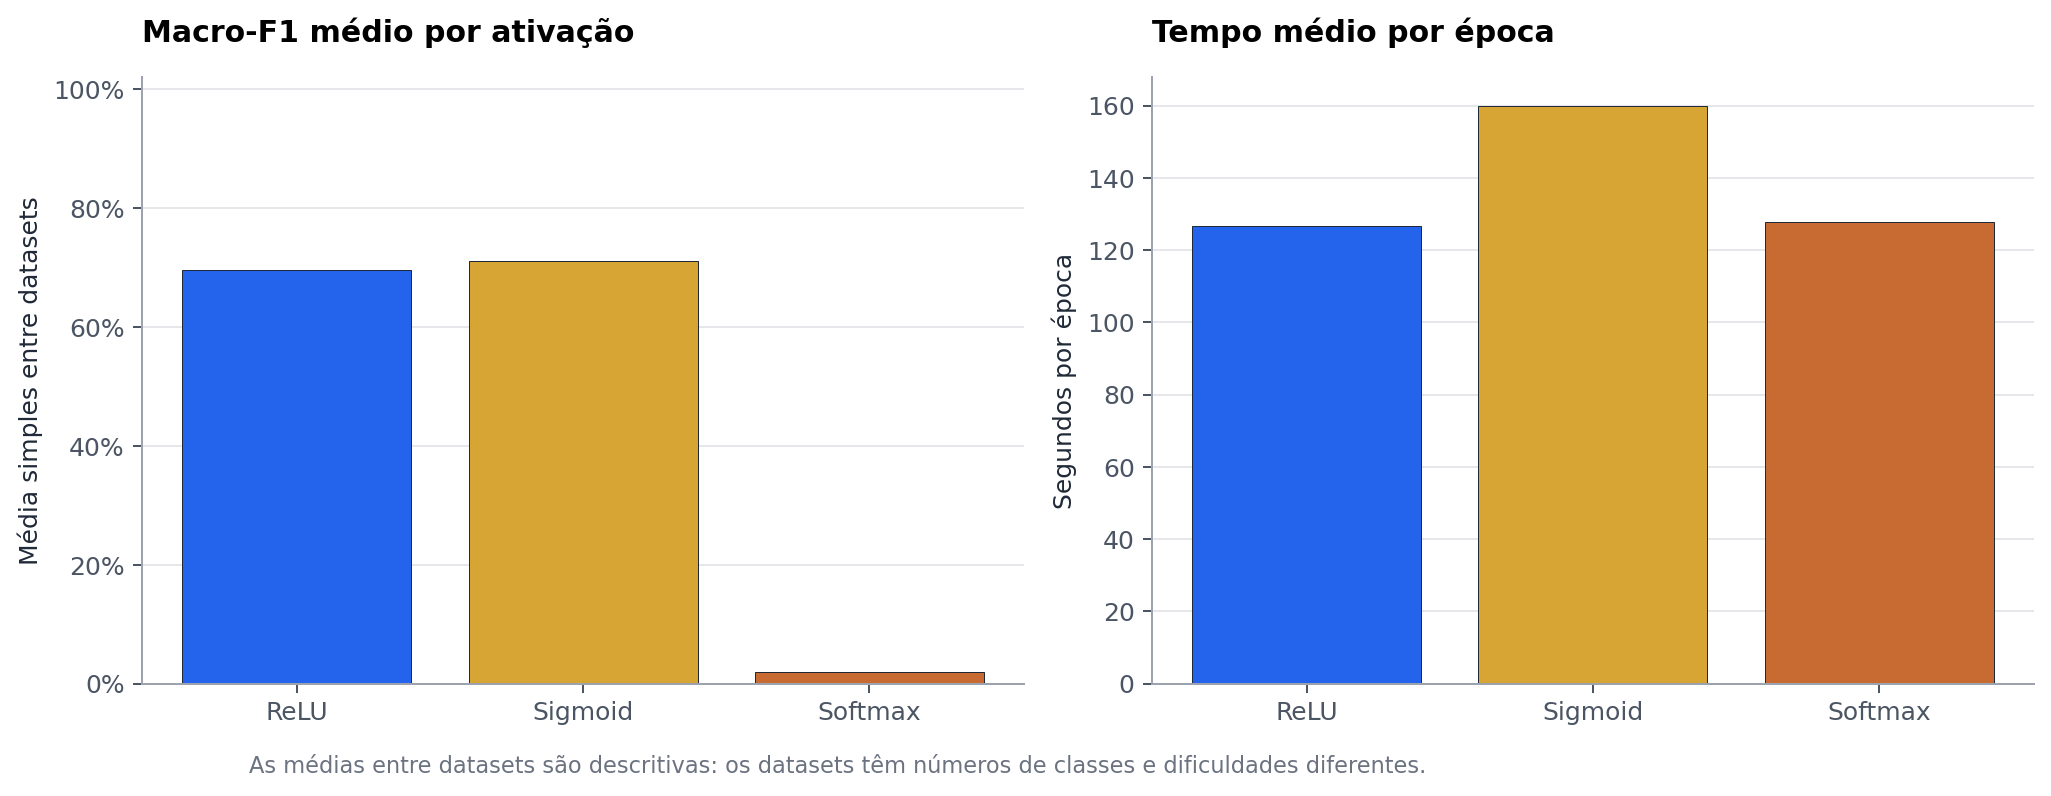

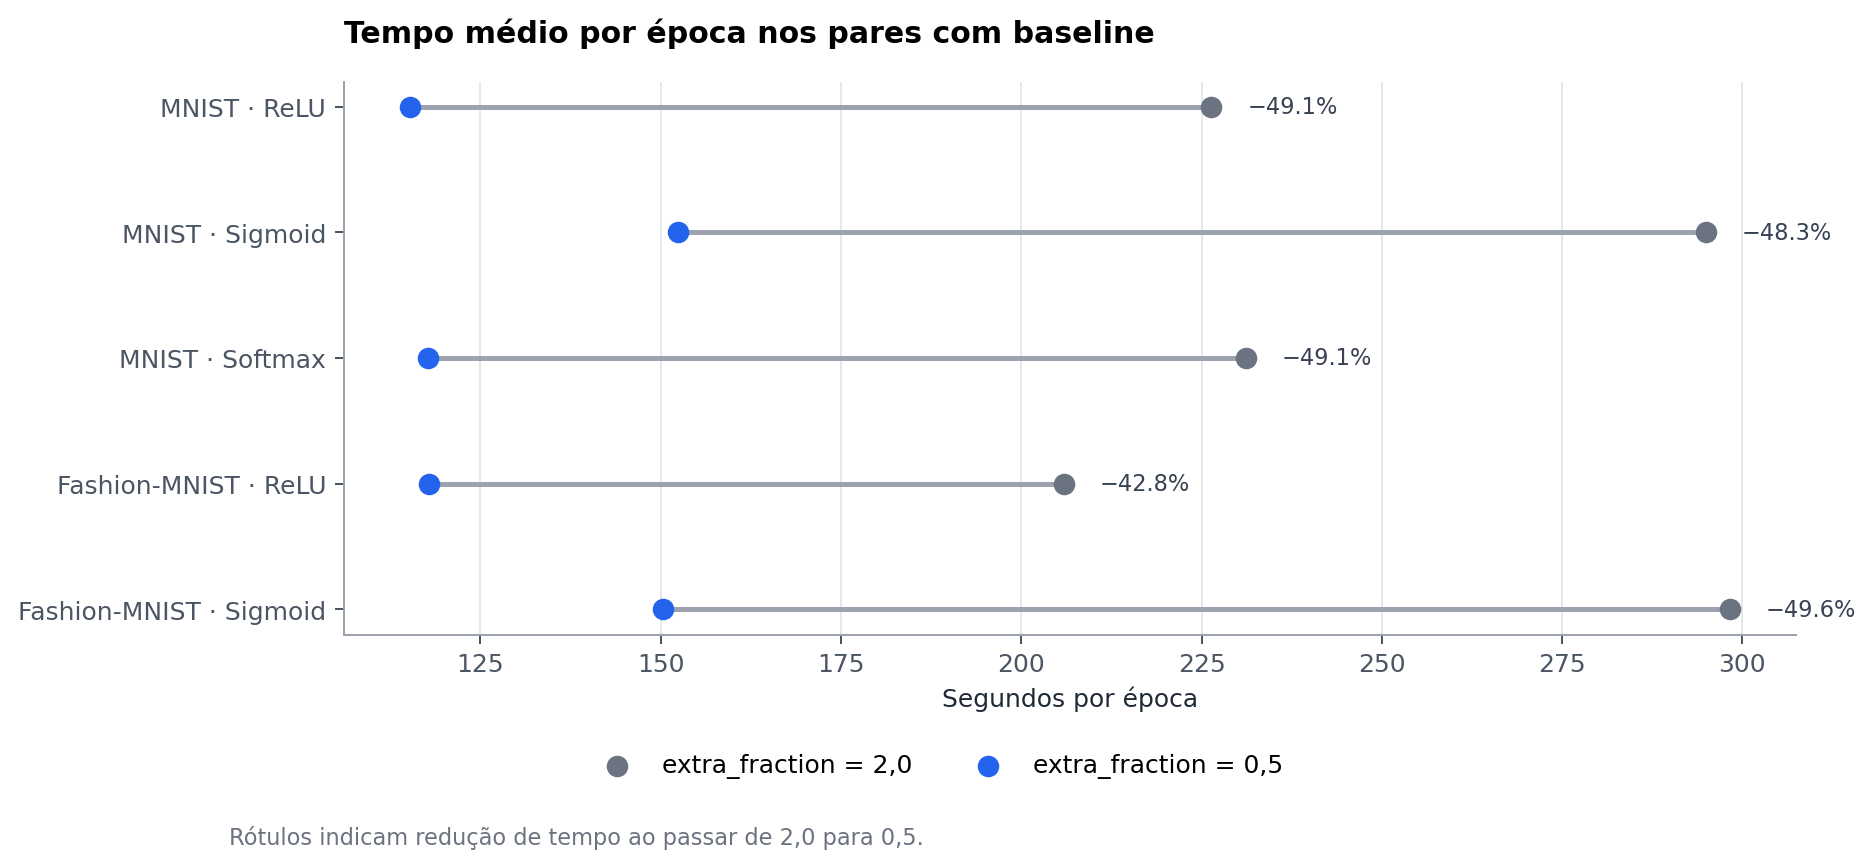

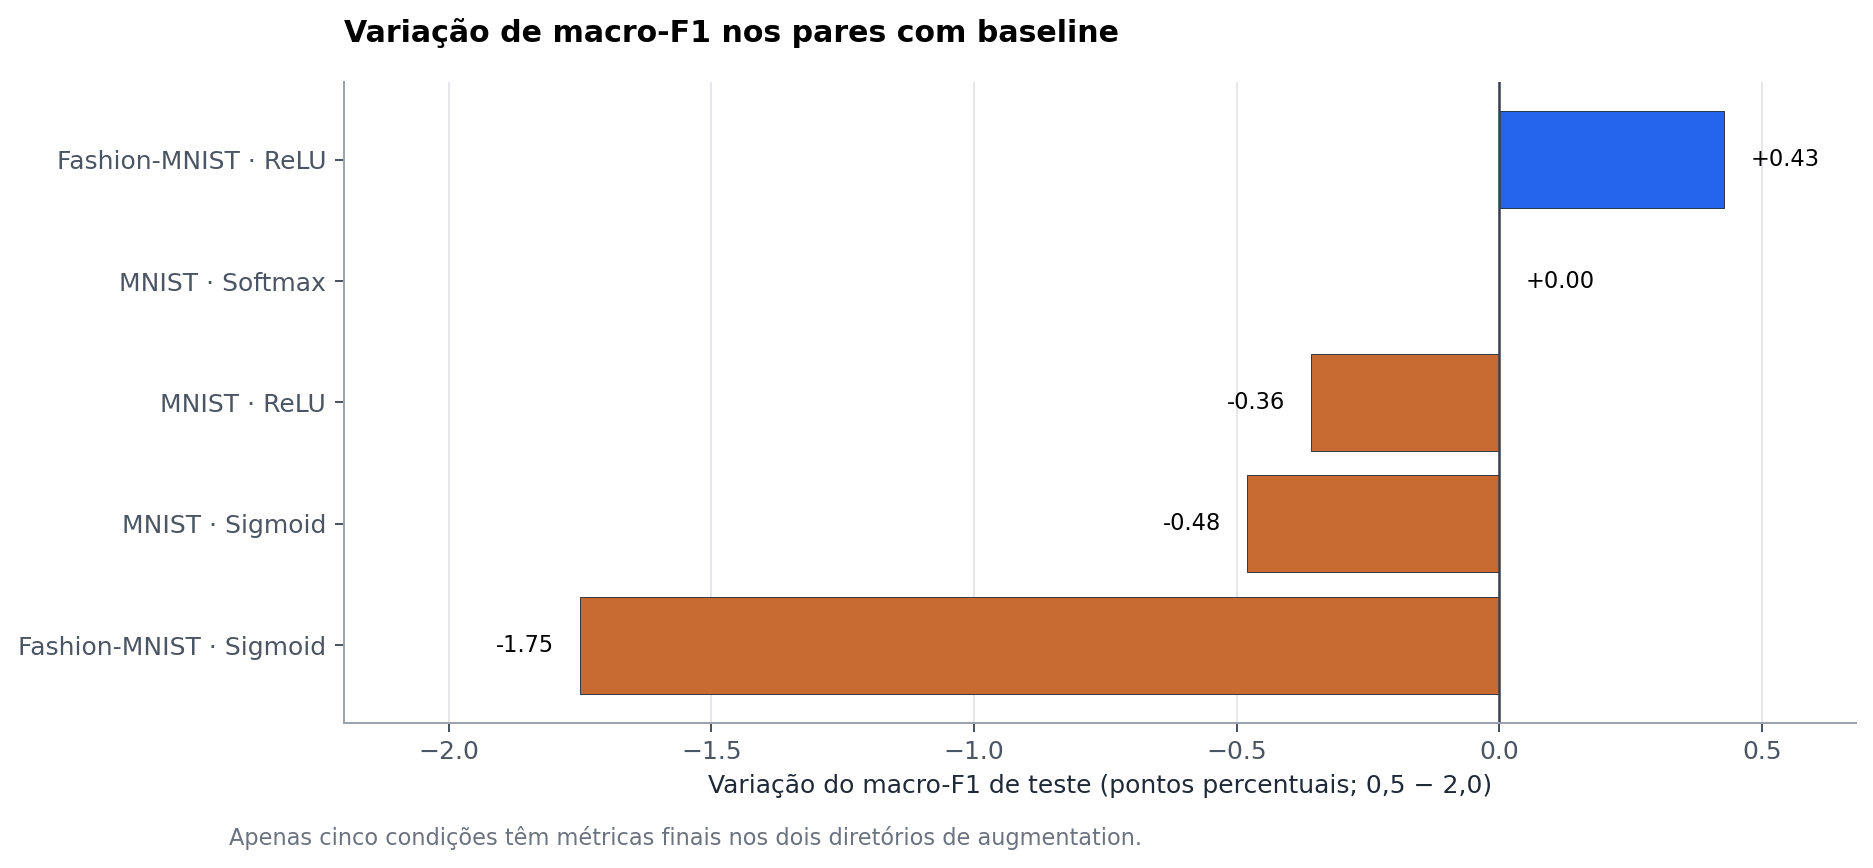

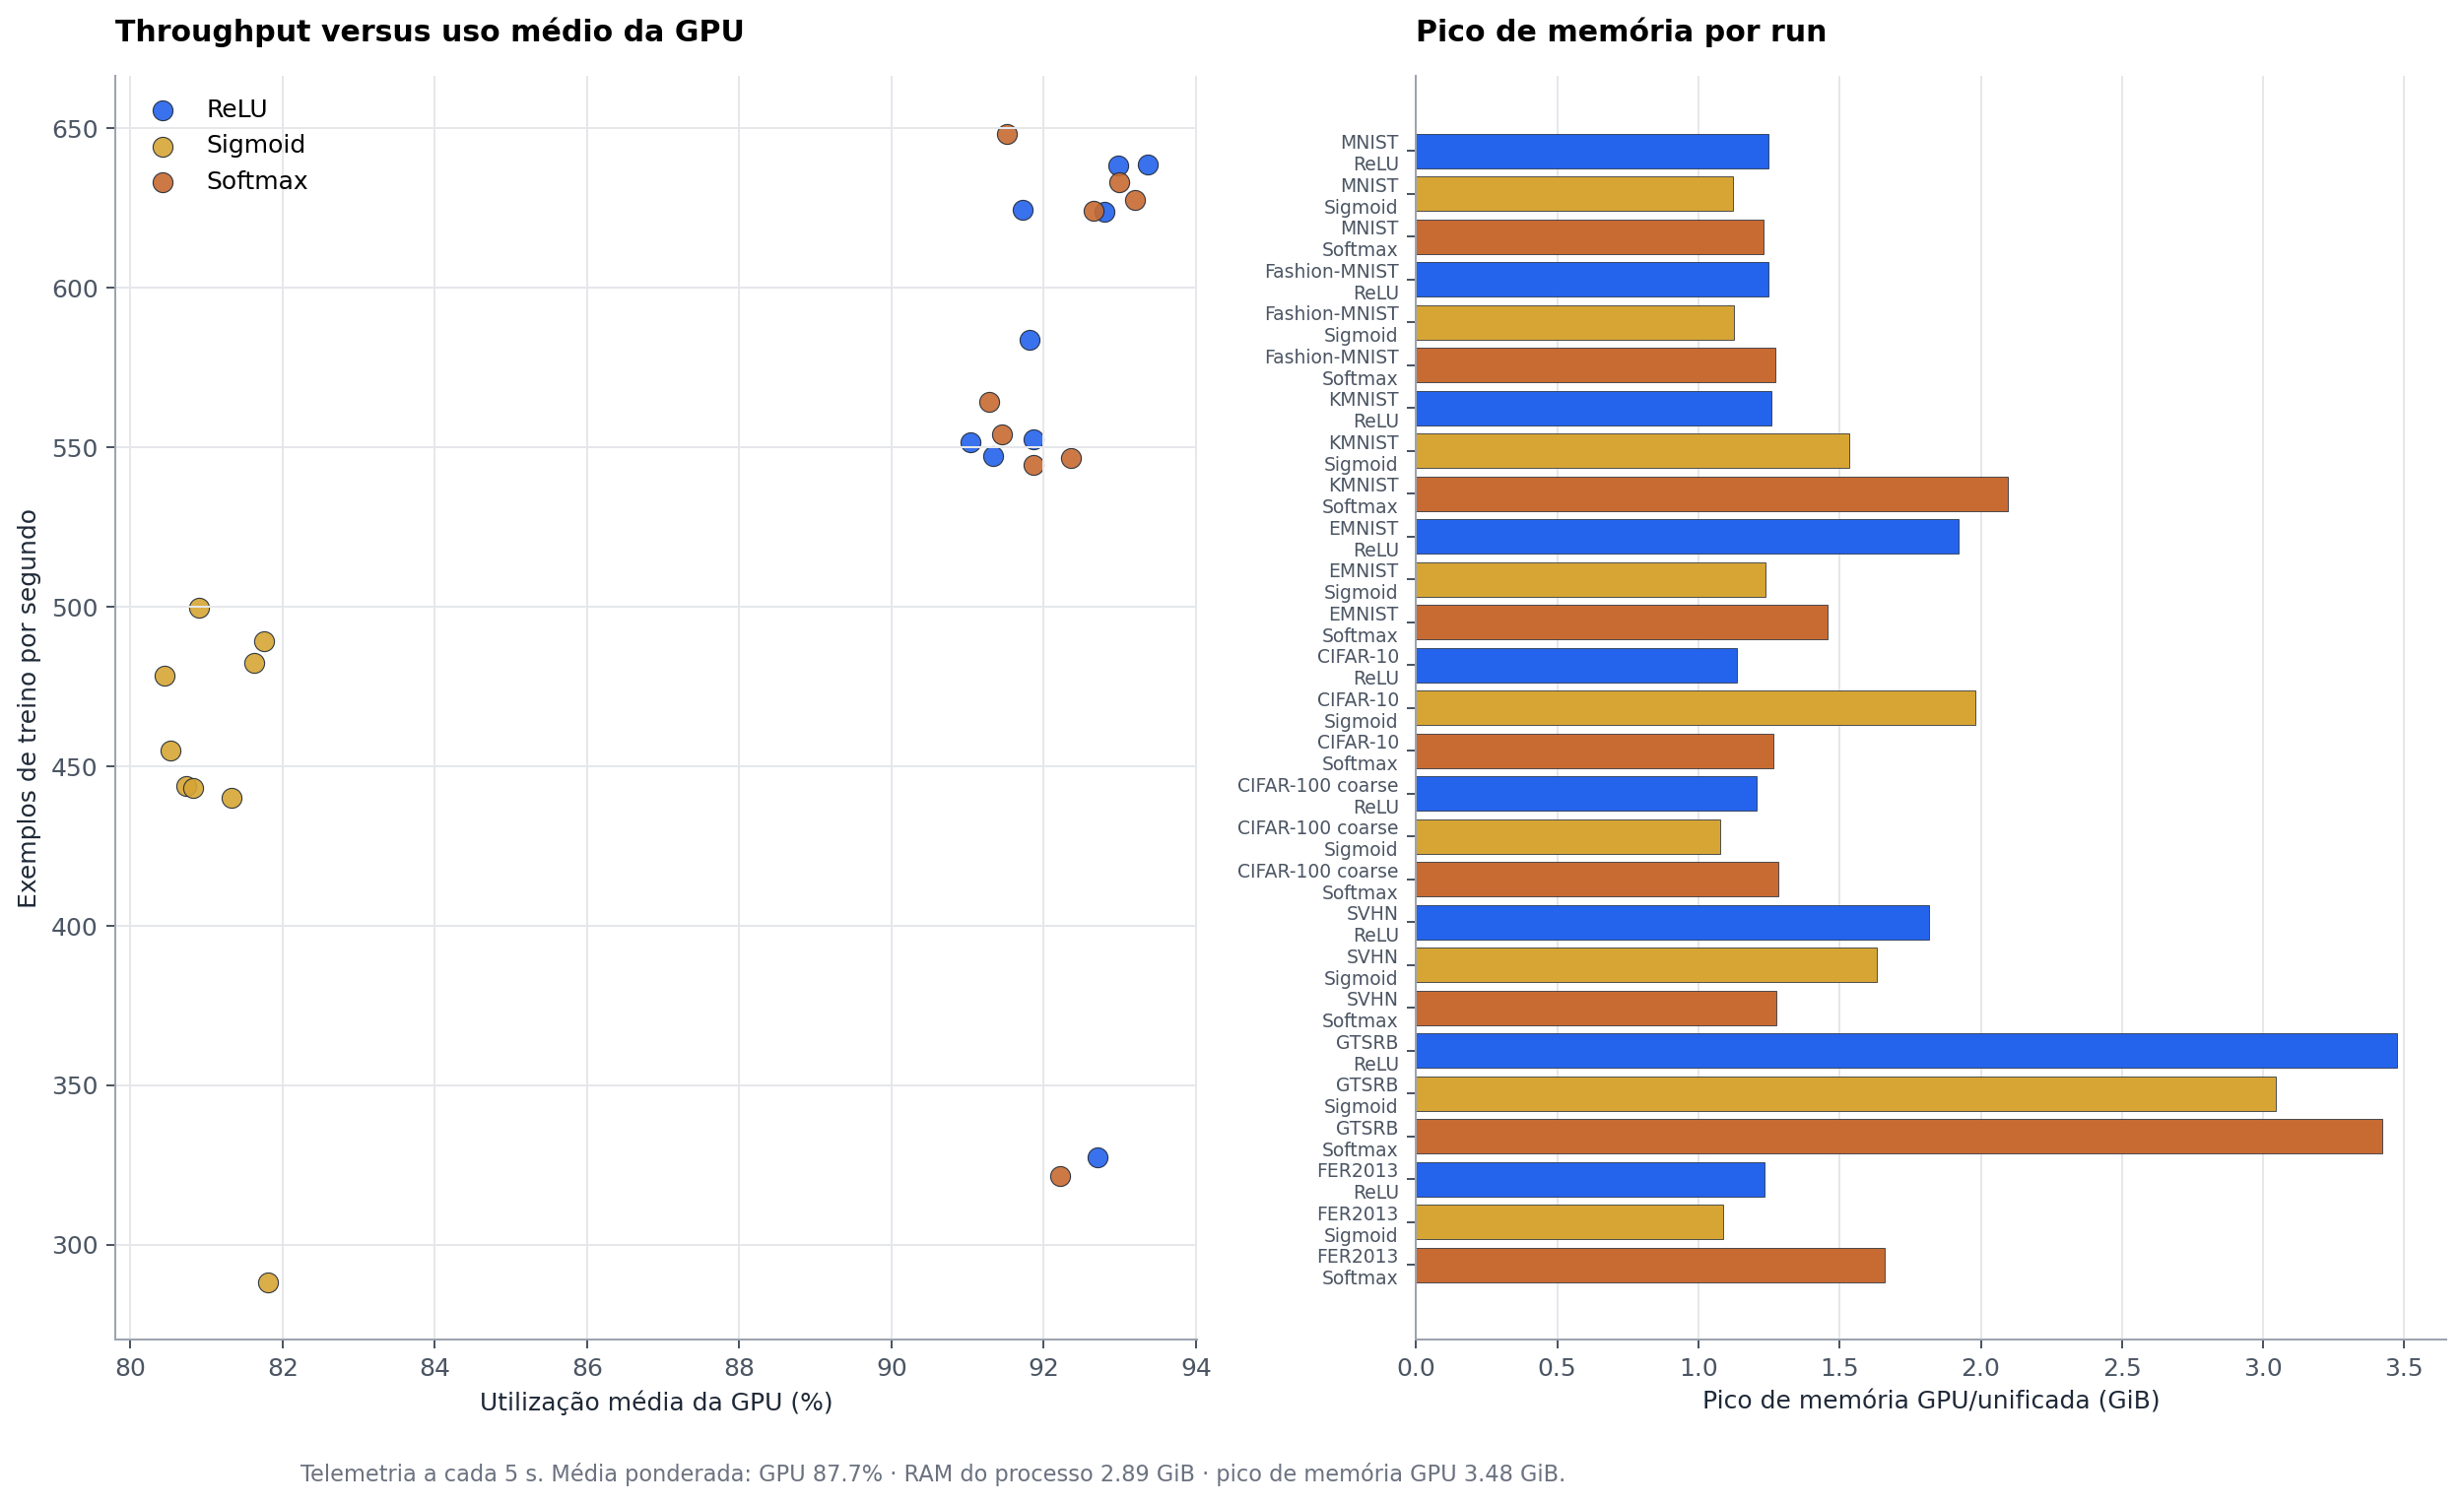

7 gráficos regenerados em docs/augmentation05_final/figures


In [4]:
figure_paths = render_figures(runs, comparison, overview, FIGURE_DIR)
for figure_path in figure_paths:
    display(Image(filename=str(figure_path), width=920))
print(f'{len(figure_paths)} gráficos regenerados em {FIGURE_DIR.relative_to(PROJECT)}')

### 5. Paired comparison against augmentation 2.0

In [5]:
comparison_columns = ['model', 'old_accuracy', 'test_accuracy', 'delta_accuracy_pp', 'old_macro_f1', 'test_macro_f1', 'delta_macro_f1_pp', 'old_mean_epoch_seconds', 'mean_epoch_seconds', 'time_reduction_pct']
comparison[comparison_columns].round(4)

,model,old_accuracy,test_accuracy,delta_accuracy_pp,old_macro_f1,test_macro_f1,delta_macro_f1_pp,old_mean_epoch_seconds,mean_epoch_seconds,time_reduction_pct
0,MNIST · ReLU,0.9874,0.9837,-0.3715,0.9872,0.9836,-0.3587,226.3550,115.1799,49.1154
1,MNIST · Sigmoid,0.9892,0.9846,-0.4668,0.9892,0.9844,-0.4796,294.9370,152.3821,48.3340
2,MNIST · Softmax,0.1125,0.1125,0.0000,0.0202,0.0202,0.0000,231.1460,117.7521,49.0573
3,Fashion-MNIST · ReLU,0.8760,0.8782,0.2190,0.8707,0.8750,0.4280,205.9089,117.8649,42.7587
4,Fashion-MNIST · Sigmoid,0.9181,0.9005,-1.7619,0.9179,0.9004,-1.7497,298.2434,150.3389,49.5919


### 6. Hardware and observed usage

In [6]:
hardware = overview['hardware']
usage = overview['hardware_usage']
pd.DataFrame([
    ('GPU', f"{hardware['gpu_name']} ({hardware['gpu_cores']} cores), {hardware['metal_version']}"),
    ('Backend', hardware['gpu_backend']),
    ('Unified memory', f"{hardware['ram_gib']:.0f} GiB"),
    ('GPU utilization', f"mean {usage['gpu_util_mean_pct']:.1f}% / peak {usage['gpu_util_max_pct']:.1f}%"),
    ('GPU shared memory', f"mean {usage['gpu_memory_mean_gib']:.2f} GiB / peak {usage['gpu_memory_peak_gib']:.2f} GiB"),
    ('Thermal pressure', str(usage['thermal_pressure_counts'])),
], columns=['Metric', 'Observed value'])

,Metric,Observed value
0,GPU,"Apple M4 (10 cores), Metal 3"
1,Backend,apple-metal-ioreg
2,Unified memory,16 GiB
3,GPU utilization,mean 87.7% / peak 100.0%
4,GPU shared memory,mean 1.04 GiB / peak 3.48 GiB
5,Thermal pressure,{'nominal': 27}


## Takeaways

- Sigmoid teve o maior macro-F1 em 8 dos 9 datasets; ReLU foi melhor no GTSRB.
- Softmax deve ser interpretado como condição degenerada neste protocolo, não como alternativa competitiva.
- A redução de `extra_fraction` diminuiu materialmente o custo de treino nos pares disponíveis, mas não preservou a qualidade de maneira uniforme.
- Há apenas uma seed por condição. Use múltiplas seeds antes de transformar as diferenças em uma decisão definitiva.